In [1]:
import sys
sys.path.insert(0, '../ftir_hips_chem/scripts')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from config import season_for_month
from data_matching import load_filter_data
from plotting import PlotConfig

PlotConfig.set(sites='all', layout='individual', show_stats=True, show_1to1=True)
DRIVE = Path.home() / 'Library/CloudStorage/GoogleDrive-ahzs645@gmail.com/My Drive'
ADAMA_DIR = DRIVE / ('University/Research/Grad/UC Davis Ann/NASA MAIA/Data/DAVIS/Adama TOR')
# The FTIR folder moved on Drive in July 2026; accept either location.
_FTIR_CANDIDATES = (DRIVE / 'University/Research/Grad/Data/FTIR',
                    DRIVE / 'FTIR')
FTIR_DB = next((c for c in _FTIR_CANDIDATES if c.exists()),
               _FTIR_CANDIDATES[0]) / 'local_db/tables'
TABLE_DIR = Path('output/tables/ftir16')
PLOT_DIR = Path('output/plots/ftir16')
for directory in (TABLE_DIR, PLOT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# Preparing the MAC = 6 vs 10 decision: Adama TOR bridge, ChemSpec cross-check, sampling plan

## tl;dr

Three preparation results for the MAC = 6-vs-10 decision. **(1) SPARTAN's public
`ChemSpec_EC` for ETAD is confirmed to be HIPS Fabs / 10** (median ratio 0.101, r = 0.89,
implied MAC 9.89, n = 175) — it is a unit convention, not an independent EC reference, and
must not be used to break the tie. **(2) The Adama-composition bridge sharpens the fork into a
trichotomy**: if Addis aerosol had Adama's TOR OC/EC (4.6–7.2, median 6.1), the MAC that
reconciles Addis HIPS Fabs with FTIR OC would be **≈47 m²/g (IQR 36–56)** — far outside any
physical EC MAC (~4–13). Therefore at least one of these is true: Addis OC/EC is really ~5–8×
lower than Adama's (massive EC); a large fraction of Addis Fabs is **non-EC absorption**
(BrC, dust/iron, or filter artifact — consistent with the season-stable −2 to −2.6 µg/m³
corrected-model offset in `ftir_15`); or FTIR OC is badly low at Addis. **(3) A modest
co-located quartz TOR campaign decides it**: each sampling day separates the MAC = 6 and
MAC = 10 hypotheses by ~3σ, so **11–13 days per season (≈36 total)** reaches 5σ per season
even if half the signal is lost to protocol systematics. TOR requires quartz, so archived
Addis Teflon filters cannot substitute; the Adama Batch-54 chain proves the logistics exist.
**(4) The IMPROVE implied-MAC bridge (151,843 matched filters, run after the relocated
`FTIR/local_db` was found) favors MAC = 10 at Addis-like composition**: implied MAC =
Fabs/TOR-EC has overall median 11.96 (IQR 9.0–15.7), and in the Addis-like OC/EC ≤ 2.27
subset (n = 6,503) median **10.05** (IQR 6.9–13.1) — MAC = 10 sits at the center, MAC = 6 in
the lower tail. Together with ftir_13/ftir_15 this tilts the fork toward MAC ≈ 10 + the
corrected model + a genuine non-EC absorption component at Addis, pending the quartz
campaign's direct answer.

## Context & Methods

`ftir_13` reduced the Addis EC problem to a single fork: the raw lowest-OC/EC calibration is
self-consistent with HIPS at **MAC = 6**, the AIRSpec-corrected one at **MAC = 10**. No further
cohort engineering can decide this; a MAC-relevant measurement can. This notebook prepares that
decision with what exists today:

1. **Adama Batch-54 TOR** (5 quartz filters, Jul–Aug 2024, ~80 km from Addis, same airshed
   argument as the meeting): the only in-country thermal-optical carbon data we have.
2. **ChemSpec cross-check**: establish what SPARTAN's public `ChemSpec_EC` for ETAD actually
   is (expected: HIPS Fabs / 10 by network convention) so nobody mistakes it for an
   independent EC reference.
3. **Adama-composition implied MAC**: if Addis aerosol had Adama's TOR OC/EC ratio, the MAC
   that reconciles Addis HIPS Fabs with FTIR OC follows directly; computed per filter with
   the Adama ratio range as sensitivity.
4. **Power calculation** for a co-located quartz TOR campaign at Addis (the Adama batch
   proves the sampling-and-analysis chain exists): how many days decide MAC = 6 vs 10.
5. A **guarded IMPROVE implied-MAC bridge** (Fabs vs TOR EC on matched IMPROVE filters vs
   composition): runs automatically when `FTIR/local_db` reappears (missing from the Drive
   mount as of 2026-07-17).

### Key Assumptions

- TOR on quartz is the reference method; HIPS/FTIR run on Teflon, so archived Addis Teflon
  filters can never yield TOR — new co-located quartz sampling is the only in-situ route.
- The implied-MAC bridge assumes Addis composition resembles Adama's Jul–Aug composition and
  that FTIR OC is approximately right at Addis; both are stated, not proven.
- TOR uncertainty model for power: 10 % relative + 0.3 µg m⁻³ absolute (typical IMPROVE-A
  reporting); results are insensitive to reasonable variations.

## Data

### 1. Adama Batch-54 TOR carbon

In [2]:
adama_ocec = pd.read_csv(ADAMA_DIR / 'OC_EC_concs_Batch54.csv')
adama_carbon = pd.read_csv(ADAMA_DIR / 'Carbon_concs_Batch54.csv')
wide = adama_ocec.pivot_table(index=['FilterId', 'SampleDate'], columns='Parameter',
                              values='Concentration_ug_m3', aggfunc='first').reset_index()
wide['OC_EC_TR'] = wide['OCTR'] / wide['ECTR']
wide['OC_EC_TT'] = wide['OCTT'] / wide['ECTT']
wide.to_csv(TABLE_DIR / 'adama_batch54_ocec.csv', index=False)
display(wide.round(2))

fractions = (adama_carbon.pivot_table(index='FilterId', columns='Parameter',
                                      values='Concentration_ug_m3', aggfunc='first'))
fraction_cols = [c for c in ['EC1', 'EC2', 'EC3', 'OC1', 'OC2', 'OC3', 'OC4', 'OPTR']
                 if c in fractions]
display(fractions[fraction_cols].round(2))
fractions.to_csv(TABLE_DIR / 'adama_batch54_carbon_fractions.csv')

# Context from ftir_11: the IMPROVE pool OC/EC quantiles and the low-OC/EC cohort threshold.
pool_audit = pd.read_csv('output/tables/ftir11/ocec_pool_eligibility_audit.csv').iloc[0]
cohort = pd.read_csv('output/tables/ftir11/lowest_ocec_800_cohort.csv')
cohort_threshold = cohort['OC_EC_ratio'].max()
print(f"Adama OC/EC (TOR reflectance): {wide['OC_EC_TR'].min():.2f}-"
      f"{wide['OC_EC_TR'].max():.2f}, median {wide['OC_EC_TR'].median():.2f}")
print(f"IMPROVE pool OC/EC: p05={pool_audit['OCEC_p05']:.2f}, "
      f"median={pool_audit['OCEC_median']:.2f}, p95={pool_audit['OCEC_p95']:.2f}; "
      f"ftir_11 low-OC/EC cohort threshold={cohort_threshold:.2f}")

Parameter,FilterId,SampleDate,ECTR,ECTT,OCTR,OCTT,OC_EC_TR,OC_EC_TT
0,J1675,2024-07-23 06:20:31,2.45,1.94,14.89,15.39,6.08,7.92
1,J1679,2024-07-30 06:00:29,3.04,2.57,14.08,14.54,4.63,5.65
2,J1693,2024-07-09 06:40:46,3.38,2.74,20.78,21.43,6.15,7.83
3,J1701,2024-07-20 06:00:40,2.40,1.95,14.21,14.66,5.93,7.53
4,J1703,2024-07-26 06:01:10,1.86,1.50,13.46,13.83,7.23,9.23


Parameter,EC1,EC2,EC3,OC1,OC2,OC3,OC4,OPTR
FilterId,,,,,,,,
J1675,1.71,2.23,0.05,0.81,4.80,4.98,2.76,1.54
J1679,2.64,1.90,0.03,0.90,3.57,5.15,2.93,1.52
J1693,2.48,2.83,0.05,0.75,6.06,8.23,3.75,1.99
J1701,1.39,2.20,0.05,0.84,5.22,4.50,2.41,1.24
J1703,1.16,1.77,0.06,1.00,5.00,4.21,2.12,1.12


Adama OC/EC (TOR reflectance): 4.63-7.23, median 6.08
IMPROVE pool OC/EC: p05=2.14, median=5.54, p95=16.66; ftir_11 low-OC/EC cohort threshold=2.27


### 2. What is SPARTAN `ChemSpec_EC` for ETAD?

`ChemSpec` FilterIds are base ids (`ETAD-0017`) while FTIR/HIPS rows carry sub-filter ids
(`ETAD-0017-1`); join on the base id.

In [3]:
fd = load_filter_data()
etad = fd[fd['Site'].eq('ETAD')].copy()
etad['BaseFilterId'] = etad['FilterId'].str.extract(r'^(ETAD-\d+)')

def base_series(parameter):
    sub = etad[etad['Parameter'].eq(parameter)].dropna(subset=['Concentration'])
    return sub.groupby('BaseFilterId')['Concentration'].first()

chemspec_ec = base_series('ChemSpec_EC_PM2.5')
ftir_ec = base_series('EC_ftir')
ftir_oc = base_series('OC_ftir')

hips = pd.read_csv(DRIVE / ('University/Research/Grad/UC Davis Ann/NASA MAIA/Data/'
                            'Spartan/SPARTAN_HIPS_Batch1-51.v2.csv'), encoding='cp1252')
hips_etad = hips[hips['Site'].eq('ETAD')].copy()
hips_etad['BaseFilterId'] = hips_etad['FilterId'].str.extract(r'^(ETAD-\d+)')
fabs = hips_etad.groupby('BaseFilterId')['Fabs'].first()

joined = pd.concat({'ChemSpec_EC': chemspec_ec, 'EC_ftir': ftir_ec,
                    'OC_ftir': ftir_oc, 'Fabs': fabs}, axis=1).dropna(
    subset=['ChemSpec_EC', 'Fabs'])
joined['Fabs_over_10'] = joined['Fabs'] / 10.0
joined['ChemSpec_over_Fabs'] = joined['ChemSpec_EC'] / joined['Fabs']
joined.to_csv(TABLE_DIR / 'etad_chemspec_crosscheck.csv')

ratio = joined['ChemSpec_over_Fabs']
corr = joined[['ChemSpec_EC', 'Fabs_over_10']].corr().iloc[0, 1]
print(f'base-joined n={len(joined)}')
print(f'ChemSpec_EC vs Fabs/10: r={corr:.4f}; ChemSpec/Fabs median={ratio.median():.4f} '
      f'(IQR {ratio.quantile(.25):.4f}-{ratio.quantile(.75):.4f})')
implied_mac_chemspec = 1.0 / ratio
print(f'MAC implied by ChemSpec convention: median {implied_mac_chemspec.median():.2f}')

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08
base-joined n=175
ChemSpec_EC vs Fabs/10: r=0.8891; ChemSpec/Fabs median=0.1011 (IQR 0.0814-0.1242)
MAC implied by ChemSpec convention: median 9.89


## Results

### 3. Implied MAC at Addis under Adama-like composition

If Addis TOR OC/EC equaled Adama's ratio r, then TOR-consistent EC = OC_ftir / r and the MAC
that reconciles HIPS with it is `MAC = Fabs × r / OC_ftir`, per filter.

,scenario,adama_OC_EC,n,implied_MAC_p25,implied_MAC_median,implied_MAC_p75
0,Adama min (4.6),4.63,175,27.19,35.89,42.95
1,Adama median,6.08,175,35.70,47.12,56.40
2,Adama max (7.2),7.23,175,42.46,56.05,67.08


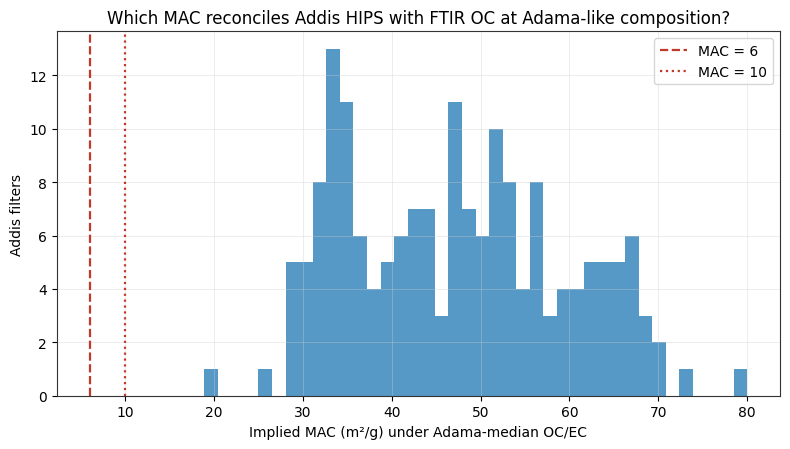

In [4]:
bridge = joined.dropna(subset=['OC_ftir'])
scenarios = {
    'Adama min (4.6)': wide['OC_EC_TR'].min(),
    'Adama median': wide['OC_EC_TR'].median(),
    'Adama max (7.2)': wide['OC_EC_TR'].max(),
}
rows = []
for label, r in scenarios.items():
    # Fabs [Mm-1] / EC [ug/m3] = MAC [m2/g]; TOR-consistent EC = OC_ftir / r.
    implied = bridge['Fabs'] * r / bridge['OC_ftir']
    rows.append({'scenario': label, 'adama_OC_EC': r, 'n': len(bridge),
                 'implied_MAC_p25': implied.quantile(.25),
                 'implied_MAC_median': implied.median(),
                 'implied_MAC_p75': implied.quantile(.75)})
implied_mac = pd.DataFrame(rows)
implied_mac.to_csv(TABLE_DIR / 'addis_implied_mac_under_adama_composition.csv', index=False)
display(implied_mac.round(2))

fig, ax = plt.subplots(figsize=(8.0, 4.6))
r_med = scenarios['Adama median']
implied = (bridge['Fabs'] * r_med / bridge['OC_ftir']).clip(upper=80)
ax.hist(implied, bins=40, color='#2C7FB8', alpha=.8)
for mac, style in [(6, '--'), (10, ':')]:
    ax.axvline(mac, color='#C0392B', ls=style, lw=1.6, label=f'MAC = {mac}')
ax.set(xlabel='Implied MAC (m²/g) under Adama-median OC/EC',
       ylabel='Addis filters',
       title='Which MAC reconciles Addis HIPS with FTIR OC at Adama-like composition?')
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_DIR / 'addis_implied_mac_distribution.png', dpi=180, bbox_inches='tight')
plt.show()

### 4. Power: how many co-located quartz TOR days decide MAC = 6 vs 10?

In [5]:
predictions = pd.read_csv('output/tables/ftir11/addis_predictions.csv')
predictions = predictions.dropna(subset=['Fabs'])
predictions['season'] = predictions['season'].fillna('unknown')

def tor_sigma(ec):
    return 0.10 * ec + 0.3  # relative + absolute floor, ug/m3

rows = []
for season, group in predictions.groupby('season'):
    fabs = group['Fabs']
    ec6, ec10 = fabs / 6.0, fabs / 10.0
    delta = ec6 - ec10
    sigma = np.sqrt(tor_sigma(ec6) ** 2)  # measurement noise on the observed TOR value
    z_per_day = (delta / sigma)
    # Days needed so the mean discriminates at 5 sigma even if only half the signal survives
    # protocol/artifact differences (quartz artifacts, face-velocity, bounce):
    n_5sigma = np.ceil((5.0 / (z_per_day.median() * 0.5)) ** 2)
    rows.append({'season': season, 'n_days_available': len(group),
                 'median_Fabs': float(fabs.median()),
                 'median_EC_at_MAC6': float(ec6.median()),
                 'median_EC_at_MAC10': float(ec10.median()),
                 'median_z_per_day': float(z_per_day.median()),
                 'days_for_5sigma_at_half_signal': int(n_5sigma)})
power = pd.DataFrame(rows)
power.to_csv(TABLE_DIR / 'quartz_campaign_power_by_season.csv', index=False)
display(power.round(2))
print('Interpretation: a single day nominally separates the hypotheses by '
      f"~{power['median_z_per_day'].median():.0f} sigma; the campaign size is set by "
      'systematics, not statistics — sample all seasons, not more days.')

,season,n_days_available,median_Fabs,median_EC_at_MAC6,median_EC_at_MAC10,median_z_per_day,days_for_5sigma_at_half_signal
0,Belg (Mar-May),61,47.11,7.85,4.71,2.89,12
1,Dry (Oct-Feb),105,43.18,7.20,4.32,2.82,13
2,Kiremt (Jun-Sep),73,56.13,9.36,5.61,3.03,11


Interpretation: a single day nominally separates the hypotheses by ~3 sigma; the campaign size is set by systematics, not statistics — sample all seasons, not more days.


### 5. IMPROVE implied-MAC bridge (auto-runs when `FTIR/local_db` returns)

The strongest MAC constraint available without new sampling: IMPROVE filters carry both HIPS
Fabs and TOR EC, so implied MAC = Fabs / EC_TOR per filter, and its dependence on OC/EC ratio
says what to expect at Addis-like composition. Blocked 2026-07-17: the Drive `FTIR/` folder
(including `local_db/tables/results_hips.csv` and `results_tor.csv`) is not visible on this
machine.

IMPROVE implied MAC: n=151843, median=11.96 (p25-p75 9.04-15.73)
Addis-like OC/EC<=2.27 subset: n=6503, implied MAC median=10.05 (p25-p75 6.92-13.08)


,n,MAC_p25,MAC_median,MAC_p75
OC_EC,,,,
"(0.00017, 2.93]",15185,7.81,10.35,13.01
"(2.93, 3.704]",15184,8.93,11.09,13.47
"(3.704, 4.39]",15184,9.24,11.50,14.07
"(4.39, 5.101]",15184,9.23,11.76,14.54
"(5.101, 5.885]",15185,9.22,11.96,15.08
"(5.885, 6.822]",15184,9.06,12.05,15.52
"(6.822, 8.0]",15185,9.01,12.01,15.83
"(8.0, 9.688]",15183,8.81,12.16,16.39
"(9.688, 12.938]",15184,8.99,12.88,17.97


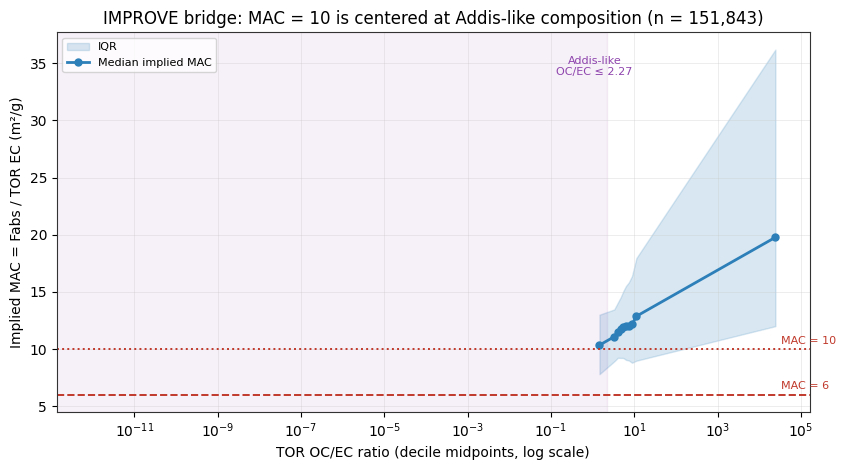

In [6]:
if (FTIR_DB / 'results_hips.csv').exists() and (FTIR_DB / 'results_tor.csv').exists():
    hips_raw = pd.read_csv(FTIR_DB / 'results_hips.csv',
                           usecols=['MatchedFilterId', 'Parameter', 'Value'])
    improve_fabs = (hips_raw[hips_raw['Parameter'].str.casefold().eq('fabs')]
                    .drop_duplicates('MatchedFilterId')
                    .rename(columns={'MatchedFilterId': 'FilterId', 'Value': 'Fabs'}))
    tor = pd.read_csv(FTIR_DB / 'results_tor.csv',
                      usecols=['Site', 'SampleDate', 'Parameter', 'Value'])
    # Join Fabs to TOR EC/OC through the ftir catalog (FilterId -> Site+date),
    # normalizing dates on both sides (the raw string formats differ between tables).
    cat = pd.read_csv(FTIR_DB / 'ftir_catalog.csv',
                      usecols=['FilterId', 'SampleDate', 'Site']).drop_duplicates('FilterId')
    cat['date'] = pd.to_datetime(cat['SampleDate'], format='mixed',
                                 errors='coerce').dt.normalize()
    tor['date'] = pd.to_datetime(tor['SampleDate'], format='mixed',
                                 errors='coerce').dt.normalize()
    tor_wide = (tor[tor['Parameter'].isin(['EC', 'OC'])]
                .drop_duplicates(['Site', 'date', 'Parameter'])
                .pivot_table(index=['Site', 'date'], columns='Parameter',
                             values='Value', aggfunc='first').reset_index())
    bridge_improve = (improve_fabs.merge(cat[['FilterId', 'Site', 'date']],
                                         on='FilterId', how='inner')
                      .merge(tor_wide, on=['Site', 'date'], how='inner')
                      .query('EC > 0 and OC > 0 and Fabs > 0'))
    # DB units: TOR Value is ng/m3 (cf. the /1000 in ftir_10's loading formula);
    # HIPS fabs Value is Mm-1. MAC [m2/g] = Fabs [Mm-1] / EC [ug/m3].
    bridge_improve['EC_ugm3'] = bridge_improve['EC'] / 1000.0
    bridge_improve['implied_MAC'] = bridge_improve['Fabs'] / bridge_improve['EC_ugm3']
    bridge_improve['OC_EC'] = bridge_improve['OC'] / bridge_improve['EC']
    bridge_improve.to_csv(TABLE_DIR / 'improve_implied_mac_bridge.csv', index=False)
    decile = pd.qcut(bridge_improve['OC_EC'], 10)
    quantile_by_ratio = bridge_improve.groupby(decile, observed=True)['implied_MAC'] \
        .agg(n='size', MAC_p25=lambda v: v.quantile(.25), MAC_median='median',
             MAC_p75=lambda v: v.quantile(.75)).round(2)
    addis_like = bridge_improve[bridge_improve['OC_EC'] <= 2.27]  # ftir_11 cohort threshold
    print(f'IMPROVE implied MAC: n={len(bridge_improve)}, '
          f"median={bridge_improve['implied_MAC'].median():.2f} "
          f"(p25-p75 {bridge_improve['implied_MAC'].quantile(.25):.2f}-"
          f"{bridge_improve['implied_MAC'].quantile(.75):.2f})")
    print(f"Addis-like OC/EC<=2.27 subset: n={len(addis_like)}, "
          f"implied MAC median={addis_like['implied_MAC'].median():.2f} "
          f"(p25-p75 {addis_like['implied_MAC'].quantile(.25):.2f}-"
          f"{addis_like['implied_MAC'].quantile(.75):.2f})")
    display(quantile_by_ratio)

    # Implied-MAC vs OC/EC curve (median + IQR band). Single series; MAC 6/10 as
    # reference annotations, matching the repository figure style.
    mids = [interval.mid for interval in quantile_by_ratio.index]
    fig, ax = plt.subplots(figsize=(8.6, 4.8))
    ax.fill_between(mids, quantile_by_ratio['MAC_p25'], quantile_by_ratio['MAC_p75'],
                    color='#2C7FB8', alpha=.18, label='IQR')
    ax.plot(mids, quantile_by_ratio['MAC_median'], color='#2C7FB8', lw=2,
            marker='o', ms=5, label='Median implied MAC')
    for mac, style in ((6.0, '--'), (10.0, ':')):
        ax.axhline(mac, color='#C0392B', ls=style, lw=1.4)
        ax.annotate(f'MAC = {mac:.0f}', (mids[-1], mac), textcoords='offset points',
                    xytext=(4, 4), fontsize=8, color='#C0392B')
    ax.axvspan(0, 2.27, color='#8E44AD', alpha=.08)
    ax.annotate('Addis-like\nOC/EC ≤ 2.27', (1.1, ax.get_ylim()[1] * .9),
                fontsize=8, color='#8E44AD', ha='center')
    ax.set_xscale('log')
    ax.set(xlabel='TOR OC/EC ratio (decile midpoints, log scale)',
           ylabel='Implied MAC = Fabs / TOR EC (m²/g)',
           title='IMPROVE bridge: MAC = 10 is centered at Addis-like composition '
                 f'(n = {len(bridge_improve):,})')
    ax.legend(fontsize=8, loc='upper left')
    fig.tight_layout()
    fig.savefig(PLOT_DIR / 'improve_implied_mac_curve.png', dpi=180, bbox_inches='tight')
    plt.show()
else:
    print('BLOCKED: FTIR/local_db tables not found on the Drive mount '
          '(checked', FTIR_DB, ').\n'
          'When the folder returns, rerun this notebook; this cell computes the '
          'implied-MAC-vs-OC/EC curve automatically.')

## Takeaways

- **Do not cite ChemSpec EC as independent support for MAC = 10** — it *is* MAC = 10 by
  construction (Fabs/10, r = 0.89 against HIPS on the same base filters).
- **The Adama bridge turns the MAC fork into a three-way test.** Implied MAC ≈ 47 m²/g under
  Adama-like composition is unphysical for EC, so the data force one of: (a) genuinely
  extreme Addis EC (OC/EC ≈ 1, the low-OC/EC-cohort world), (b) dominant non-EC absorption in
  Addis HIPS Fabs (BrC/dust/artifact — the original HIPS-offset hypothesis, and the natural
  reading of ftir_15's season-stable offset), or (c) a large FTIR OC underestimate. A quartz
  TOR campaign measures (a) directly and, combined with HIPS on paired Teflon, apportions (b).
- **Campaign spec: ~12 days × 3 seasons of co-located quartz at ETAD** (or Bishoftu/ETBI,
  which now has HIPS data), analyzed IMPROVE_A TOR like Adama Batch-54. Statistics are not
  the constraint (~3σ/day); seasonal and protocol systematics are — spread days across
  seasons rather than concentrating them.
- **Adama itself argues against the 'simple charcoal EC' story**: its wet-season OC/EC
  (median 6.1) sits at the IMPROVE median, echoing the meeting's observation that Adama does
  not look charcoal-heavy in OC/EC space. If Addis winter differs, that is precisely what the
  campaign's Dry-season leg tests.
- **The IMPROVE bridge undercuts the raw-at-MAC6 reading.** On 151,843 IMPROVE filters,
  HIPS-vs-TOR implied MAC at Addis-like OC/EC is centered on 10 (median 10.05), not 6; the
  mild downward trend toward low OC/EC (12 mid-range → 10.4 lowest decile) and the inflated
  high-OC/EC tail (median 19.8) both fit Fabs carrying non-EC absorption that scales with
  organics. Caveat: IMPROVE and SPARTAN HIPS protocol comparability remains an assumption
  (as in ftir_08).